# Uczenie głębokie 

## laboratorium: Sztuczne sieci neuronowe w keras

Najważniejsze koncepcje :
-   Aktywacje
-   Warstwy

# Zadanie 1

Zbadać własności uniwersalnej aproksymacji funkcji an przykładzie nastepujacej funkcji.
W tym celu należy dopasować małą sieć neuronową do danych pochodzących z funkcji i narysować na jednym wykresie funkcję i jej neuronowe przybliżenie.

Zbadać wpływ :

1. Liczby warstw
1. Liczby neuronów w warstwie (dla uproszczenia przyjąć taką samą liczbę neuronów w każdej warstwie ukrytej)
1. Funkcji aktywacji, koniecznie porównać `relu` i jedną z funkcji sigmoidalnych np. `sigmoid` lub `tanh`


In [1]:
import numpy as np

def staircaise_function(x):
    p=np.poly(-np.array([-1,-0.5,0.5,1]))
    smooth = np.polyval(p,x)/0.2
    return np.ceil(smooth),smooth


<Axes: >

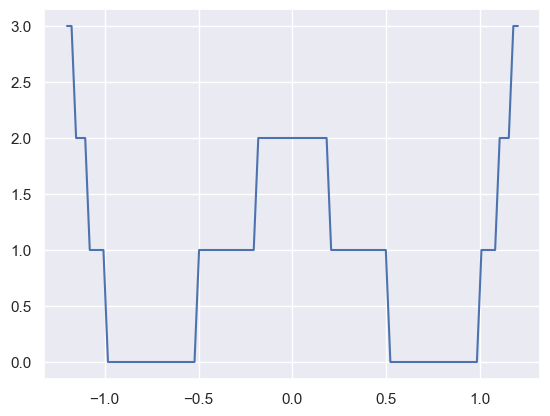

In [2]:
import seaborn as sns
sns.set_theme()

x = np.linspace(-1.2,1.2,100)
y,ysmooth = staircaise_function(x)

sns.lineplot(x=x,y=y)


In [3]:
xtrain = np.random.uniform(low=x[0],high=x[-1],size=(128,1))
ytrain,_ = staircaise_function(xtrain)

In [9]:
# TODO
import os
os.environ["KERAS_BACKEND"] = "jax"
import keras

model = keras.Sequential([
    #keras.layers.Dense(2,activation='tanh'),
    #keras.layers.Dense(2,activation='tanh'),

    #keras.layers.Dense(4,activation='tanh'),

    #keras.layers.Dense(32,activation='tanh'),
    #keras.layers.Dense(32,activation='tanh'),

    #keras.layers.Dense(64,activation='tanh'),
    #keras.layers.Dense(64,activation='tanh'),
    #keras.layers.Dense(64,activation='tanh'),

    #keras.layers.Dense(8,activation='relu'),
    keras.layers.Dense(18,activation='softplus'),
    keras.layers.Dense(1),
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-2),
    loss=keras.losses.MeanSquaredError()
)

h=model.fit(xtrain,ytrain,epochs=6000,verbose=0)

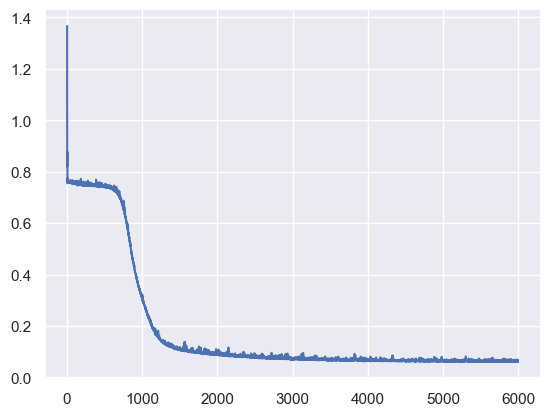

In [10]:
import matplotlib.pyplot as plt
plt.plot(h.history['loss'])

In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (32, 18)               │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 1)                │            19 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167 (668.00 B)

 Trainable params: 55 (220.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 112 (448.00 B)

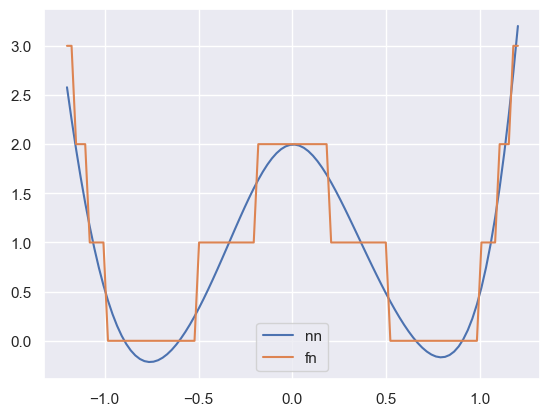

In [12]:
plt.plot(x,model(x), label='nn')
plt.plot(x,y, label='fn')
plt.legend()

# Zadanie 2

W tym zadaniu popracujemy na prawdziwych danych, uzywanych w poprzednim tygodniu, czyli na napisach filmowych.
Trzeba zbudować sieć, która przewiduje jaki jaki będzie nastepny znak na podstawie poprzedniego.
Uwaga, dla $n$ mozliwych znakow mozemy oszacować prosty model tablicowy , który ma $n(n-1)$ parametrow, więc siec neuronowa musi mieć mniej parametrów zby mieć zysk z zastosowania trenowalnego modelu. Porównać wyniki klasyfikacji dla wytrenowanego modelu oraz prostego modelu tablicowego.

## Uwaga

Sprawdzić dwie reprezentację zmiennej kategorycznej: (numeryczna i one-hot).

## Lepszy model

Jak się zmieni skuteczność modelu jeżeli dodamy dwa poprzednie symbole jako wejście? W takim przypadku naiwny model tabliocwy potrzebuje $n^2(n-1)$ parametrów, więc widac że podejście tablicowe szybko staje sie niepraktyczne.

In [16]:
from numpy.lib.stride_tricks import sliding_window_view

fname = "./Star.Trek.Picard.S01E01.PROPER.WEBRip.x264-ION10.srt"

with open(fname, "r", encoding="cp1250") as f:
    txt = f.read()

u = list(set(txt))

data = np.asarray([u.index(l) for l in txt])
n = len(u)



window=3
xy = sliding_window_view(data, window)
X=xy[:,0:-1]
y = xy[:,1]
nin=n

if window == 3:
    X = X@ np.asarray([[n],[1]])
    nin=n**2

In [17]:
X[1:5]

array([[6451],
       [  87],
       [  97],
       [ 947]])

In [18]:
n**2*(n-1)


628660

In [19]:
import os
os.environ["KERAS_BACKEND"] = "jax"
import keras

model=keras.Sequential([
    keras.layers.CategoryEncoding(num_tokens=nin, output_mode="one_hot"),
    keras.layers.Dense(4,activation='relu'),
    keras.layers.Dense(n)
])

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True)
)

In [21]:
h=model.fit(X,y,batch_size=256, validation_split=0.2, epochs=50,verbose=0)

<Axes: >

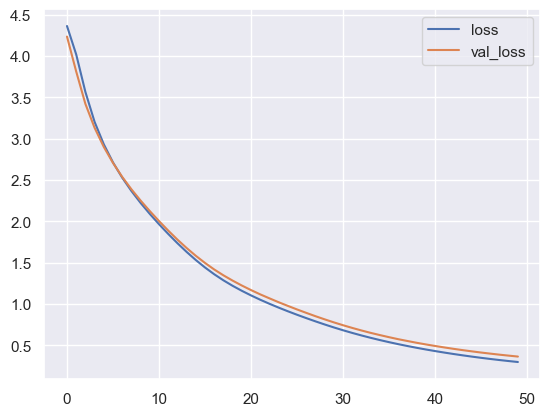

In [22]:
import pandas as pd
pd.DataFrame(h.history).plot()

In [23]:
import os
os.environ["KERAS_BACKEND"] = "jax"
import keras

tab=keras.Sequential([
    keras.layers.CategoryEncoding(num_tokens=n, output_mode="one_hot"),
    keras.layers.Dense(n)
])

tab.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True)
)
ht = tab.fit(X,y, batch_size=256, validation_split=0.2, epochs=100, verbose=0)
 

<Axes: >

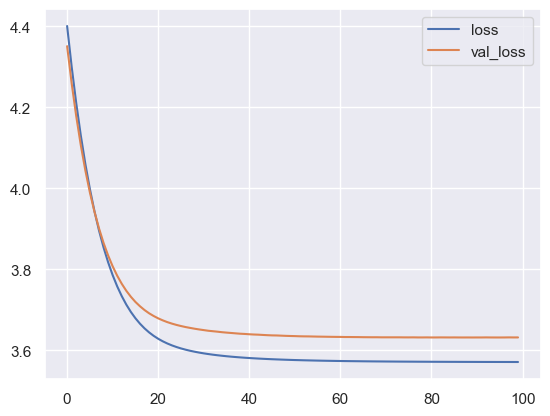

In [24]:
import pandas as pd
pd.DataFrame(ht.history).plot()